# TRIP Toughening Submodel — Patel-Cohen + Olson-Cohen

Phase 3 walkthrough. Reverted austenite films at lath boundaries can
transform to martensite under stress (Patel-Cohen) or strain (Olson-Cohen)
at the crack tip — the volume-expanding γ→α′ transformation provides crack-tip
shielding. This notebook:

1. Reproduces Patel-Cohen 1953 Table I dM_s/dσ slopes for Fe-Ni alloys.
2. Reproduces Olson-Cohen 1975 / Angel 1954 304 SS f_α′(ε) curves.
3. Sets up the M54 calibration from your cw/cr austenite measurements.

See [`index/trip-foundations-index.md`](../index/trip-foundations-index.md) for
the full equation derivation.

## 0. Setup

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

from m54model.toughening import (
    OlsonCohenParams, olson_cohen_volume_fraction, fit_olson_cohen,
    patel_cohen_max_work, patel_cohen_ms_shift, patel_cohen_optimal_orientation,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. Patel-Cohen 1953 — stress-assisted γ → α′ M_s shift

For Fe-Ni alloys with γ₀ = 0.20 (transformation shear) and ε₀ = 0.04 (dilatation),
the optimal habit-plane orientation maximizing U = τγ₀ + σε₀ is at 2θ ≈ 79°.

In [2]:
GAMMA0, EPS0 = 0.20, 0.04
DF_DT_FE_NI_C = 1.33  # cal/(mol·K) for 0.5C-20Ni-bal-Fe
DF_DT_FE_NI = 1.23   # cal/(mol·K) for 70Fe-30Ni
VM = 7.1e-6           # m³/mol austenite molar volume
ONE_KSI_MPA = 6.895

theta_opt = patel_cohen_optimal_orientation(GAMMA0, EPS0)
print(f'Optimal habit-plane angle: 2θ = {math.degrees(2*theta_opt):.2f}° (PC: 78.7°)')
print()
print('dM_s/dσ for Fe-Ni-C alloys (PC 1953 Table I anchors):')
for mode, dF_dT, expected in [
    ('tension',     DF_DT_FE_NI_C,  '+1.07'),
    ('compression', DF_DT_FE_NI_C,  '+0.72'),
    ('hydrostatic', DF_DT_FE_NI,    '-0.38'),
]:
    dMs = patel_cohen_ms_shift(ONE_KSI_MPA, GAMMA0, EPS0, dF_dT, VM, mode=mode)
    print(f'  {mode:13s}: model {dMs:+5.2f} °C/ksi   PC says {expected} °C/ksi')

Optimal habit-plane angle: 2θ = 78.69° (PC: 78.7°)

dM_s/dσ for Fe-Ni-C alloys (PC 1953 Table I anchors):
  tension      : model +1.07 °C/ksi   PC says +1.07 °C/ksi
  compression  : model +0.65 °C/ksi   PC says +0.72 °C/ksi
  hydrostatic  : model -0.38 °C/ksi   PC says -0.38 °C/ksi


### M_s shift vs applied stress — visualize across all three loading modes

Patel-Cohen 1953 Fig. 1 reproduction. Tension > compression because both
shear and normal components aid transformation under tension; in compression
the normal component opposes the +4 % volume expansion of γ→α′.

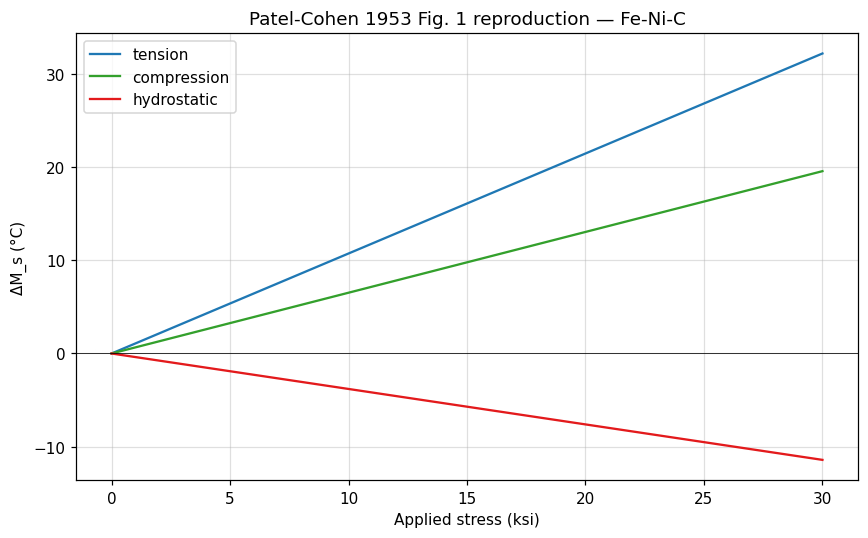

In [3]:
sigma_ksi = np.linspace(0, 30, 30)
sigma_MPa = sigma_ksi * ONE_KSI_MPA

fig, ax = plt.subplots(figsize=(8, 5))
for mode, dF_dT, color in [
    ('tension',     DF_DT_FE_NI_C,  '#1f78b4'),
    ('compression', DF_DT_FE_NI_C,  '#33a02c'),
    ('hydrostatic', DF_DT_FE_NI,    '#e31a1c'),
]:
    dMs = [patel_cohen_ms_shift(s, GAMMA0, EPS0, dF_dT, VM, mode=mode) for s in sigma_MPa]
    ax.plot(sigma_ksi, dMs, '-', color=color, label=mode)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Applied stress (ksi)')
ax.set_ylabel('ΔM_s (°C)')
ax.set_title('Patel-Cohen 1953 Fig. 1 reproduction — Fe-Ni-C')
ax.legend()
ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

## 2. Olson-Cohen 1975 — strain-induced kinetics

Master equation:  f_α′(ε) = 1 − exp{−β · [1 − exp(−α · ε)]ⁿ}

where α captures shear-band-formation rate (depends on stacking-fault energy)
and β captures the probability that a shear-band intersection nucleates an
α′ embryo (sigmoidal in T, saturates near 2.0 at low T, decays to 0 above M_d).

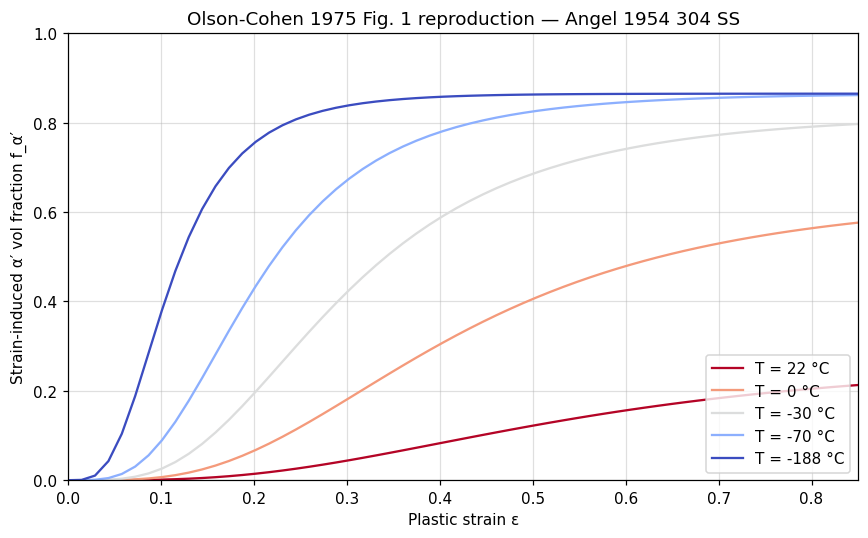

In [4]:
# Angel 1954 304 SS, Olson-Cohen Fig. 2(a, b) parameters at five temperatures.
ANGEL_PARAMS = {
    -188: OlsonCohenParams(alpha=12.9,  beta=2.00, n=4.5, T_celsius=-188),
     -70: OlsonCohenParams(alpha=7.0,   beta=2.00, n=4.5, T_celsius=-70),
     -30: OlsonCohenParams(alpha=5.0,   beta=1.70, n=4.5, T_celsius=-30),
       0: OlsonCohenParams(alpha=4.0,   beta=1.00, n=4.5, T_celsius=0),
      22: OlsonCohenParams(alpha=3.55,  beta=0.30, n=4.5, T_celsius=22),
}

eps = np.linspace(0, 0.85, 60)
fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.get_cmap('coolwarm_r')
Ts = sorted(ANGEL_PARAMS, reverse=True)
for i, T in enumerate(Ts):
    p = ANGEL_PARAMS[T]
    fa = [olson_cohen_volume_fraction(e, p) for e in eps]
    ax.plot(eps, fa, '-', color=cmap(i / max(1, len(Ts)-1)), label=f'T = {T} °C')
ax.set_xlabel('Plastic strain ε')
ax.set_ylabel('Strain-induced α′ vol fraction f_α′')
ax.set_title('Olson-Cohen 1975 Fig. 1 reproduction — Angel 1954 304 SS')
ax.legend(loc='lower right')
ax.grid(alpha=0.4)
ax.set_xlim(0, 0.85)
ax.set_ylim(0, 1.0)
fig.tight_layout()
plt.show()

### Fitter sanity check

Generate synthetic data from a known α, β; verify the fitter recovers them.

In [5]:
true_p = OlsonCohenParams(alpha=12.9, beta=2.0, n=4.5, T_celsius=-188)
eps_obs = np.linspace(0.05, 0.6, 12)
f_obs = [olson_cohen_volume_fraction(e, true_p) for e in eps_obs]
fit = fit_olson_cohen(list(eps_obs), f_obs, n=4.5, T_celsius=-188)
print(f'True:  α={true_p.alpha:.3f}, β={true_p.beta:.3f}')
print(f'Fit:   α={fit.alpha:.3f}, β={fit.beta:.3f}')
print(f'Error: Δα/α = {abs(fit.alpha-true_p.alpha)/true_p.alpha*100:.2f} %, Δβ/β = {abs(fit.beta-true_p.beta)/true_p.beta*100:.2f} %')

True:  α=12.900, β=2.000
Fit:   α=12.900, β=2.000
Error: Δα/α = 0.00 %, Δβ/β = 0.00 %


## 3. M54 cw/cr austenite data — and the non-monotonic finding

ASTAR precession-diffraction-mapped FCC γ phase fractions at 0/20/40/60 %
cumulative cold rolling, both at the rolling **surface** and through-thickness
**core** (median along ND-midplane). Surface error bars are 1σ from multiple
ASTAR maps.

**Surprise:** austenite content is *non-monotonic* in CR. It drops from
0 → 20 % CR (classical TRIP — austenite converts to α′), then **rises sharply**
at 40 % CR (the surface jumps from 0.5 % to 26.4 %!), and partially retransforms
at 60 %. This is *not* what Olson-Cohen describes. See FINDINGS.md §5 for the
full discussion of candidate mechanisms (adiabatic-heating-driven reverse
transformation, mechanical austenite formation in shear-band cellular networks,
TWIP-like substructure stabilization).

In [6]:
from m54model.calibration.user_trip_data import (
    USER_M54_CW_AUSTENITE_SURFACE,
    USER_M54_CW_AUSTENITE_CORE,
    cw_pct_to_true_strain,
)

for label, data in [('surface', USER_M54_CW_AUSTENITE_SURFACE),
                     ('core',    USER_M54_CW_AUSTENITE_CORE)]:
    print(f'=== {label} ===')
    for p in data:
        std = f' ± {p.f_austenite_std:.3f}' if p.f_austenite_std else ''
        eps_eq = cw_pct_to_true_strain(p.cw_pct) if p.cw_pct > 0 else 0.0
        print(f'  CR={p.cw_pct:4.0f}%  ε={eps_eq:.3f}  f_A = {p.f_austenite:.3f}{std}')
    print()

=== surface ===
  CR=   0%  ε=0.000  f_A = 0.013 ± 0.009
  CR=  20%  ε=0.223  f_A = 0.005 ± 0.003
  CR=  40%  ε=0.511  f_A = 0.264 ± 0.090
  CR=  60%  ε=0.916  f_A = 0.176 ± 0.080

=== core ===
  CR=   0%  ε=0.000  f_A = 0.026
  CR=  20%  ε=0.223  f_A = 0.013
  CR=  40%  ε=0.511  f_A = 0.099
  CR=  60%  ε=0.916  f_A = 0.126



### Plot the data — the spike at 40 % CR is the central finding

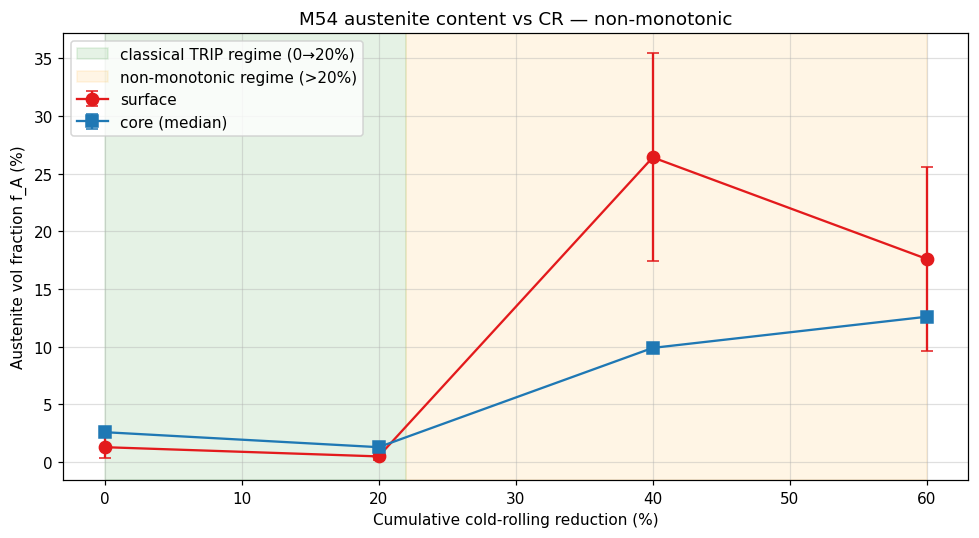

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for data, color, marker, label in [
    (USER_M54_CW_AUSTENITE_SURFACE, '#e31a1c', 'o', 'surface'),
    (USER_M54_CW_AUSTENITE_CORE,    '#1f78b4', 's', 'core (median)'),
]:
    cws = [p.cw_pct for p in data]
    fas = [p.f_austenite * 100 for p in data]
    err = [(p.f_austenite_std or 0) * 100 for p in data]
    ax.errorbar(cws, fas, yerr=err, marker=marker, color=color, label=label, markersize=8, capsize=4)
ax.axvspan(0, 22, color='green', alpha=0.10, label='classical TRIP regime (0→20%)')
ax.axvspan(22, 60, color='orange', alpha=0.10, label='non-monotonic regime (>20%)')
ax.set_xlabel('Cumulative cold-rolling reduction (%)')
ax.set_ylabel('Austenite vol fraction f_A (%)')
ax.set_title('M54 austenite content vs CR — non-monotonic')
ax.legend()
ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

### Try the fit — and observe why it fails

Calling `m54_olson_cohen_fit_from_user_data` with the default
`fit_only_monotonic_prefix=True` raises because the monotonic prefix has only
two points. If we *force* a fit on all 4 points, the optimizer rails α to its
upper bound — a clear signal the model is wrong for this data.

In [8]:
from m54model.calibration.user_trip_data import m54_olson_cohen_fit_from_user_data

try:
    m54_olson_cohen_fit_from_user_data(USER_M54_CW_AUSTENITE_SURFACE)
except ValueError as e:
    print(f'Default (safe) fit refused: {e}')
print()

fit_anyway = m54_olson_cohen_fit_from_user_data(
    USER_M54_CW_AUSTENITE_SURFACE, fit_only_monotonic_prefix=False
)
print(f'Forced fit on all 4 points: α={fit_anyway.alpha:.2f}, β={fit_anyway.beta:.2f}')
print('  → α railed to its upper bound; the fit is meaningless.')

Default (safe) fit refused: need >=3 points to fit (α, β); got 2. M54 data has only 2 monotonic points (0 → 20 % CR); use `fit_only_monotonic_prefix=False` to fit all data and accept the bad fit, or supply a finer-resolution dataset.

Forced fit on all 4 points: α=50.00, β=0.23
  → α railed to its upper bound; the fit is meaningless.


### Interpretation

Until we model the austenite-formation/stabilization mechanism that kicks in
above ~20 % CR, the path forward for crack-tip TRIP modeling is:

- **Use Olson-Cohen with literature-analog (α, β)** — e.g., Cho 2015 H600 Co-Ni
  values, or 304 SS at room temperature — explicitly noting this as a
  Phase 3.5 calibration gap.
- **Restrict any quantitative TRIP claim to the 0 → 20 % CR regime** for now.
- **Scope a Phase 3.6 model** that combines forward γ→α′ (Olson-Cohen) with a
  competing α′→γ reverse mechanism (likely thermally-driven from rolling-surface
  adiabatic heating, or strain-localized via shear-band cellular substructure).
  The 4:1 surface:core ratio at 40 % CR is the smoking gun for surface-localized
  heating or shear partitioning.

## 4. Where this goes next — Phase 3.5

With (α, β) calibrated for M54 reverted austenite, the next deliverable is
a **crack-tip TRIP K_IC contribution**:

1. At the crack tip, compute the local stress + strain field (HRR or
   calibrated effective-stress proxy).
2. For each material point in the plastic zone:
   - Apply Patel-Cohen `U = τγ₀ + σε₀` to find stress-assisted shift in M_s.
   - If the local point is above M_s^σ but ε_p > 0, apply Olson-Cohen with
     calibrated (α, β) to compute strain-induced f_α′.
3. Sum the volume of newly-transformed α′ in the plastic zone.
4. Compute the volume-expansion-induced compressive residual stress field around
   the crack tip → **ΔK_IC** (toughening contribution).
5. Validate against Mondière's M54 commercial K_IC = 110 MPa·m^(1/2).

All the pieces are in place; the synthesis is Phase 3.5 work.